In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.pipeline import Pipeline
from sklearn.metrics import recall_score , precision_score
from sklearn.preprocessing import PolynomialFeatures
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd

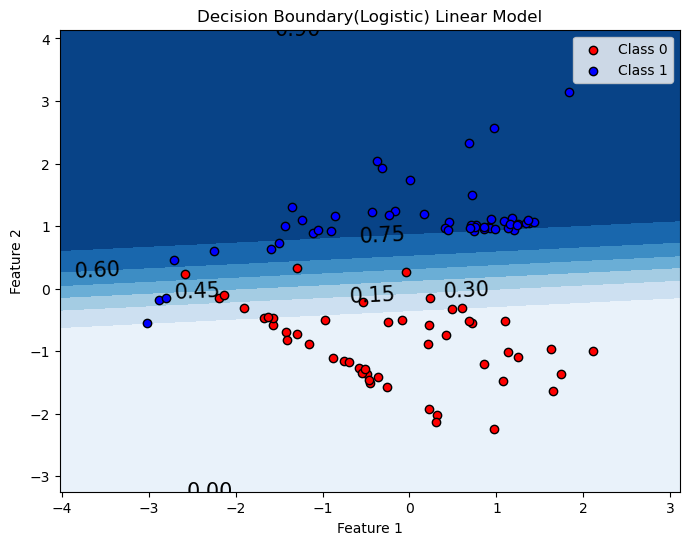

In [2]:
model = LogisticRegression()

X, y = make_classification(n_samples=100,
                           n_features=2,
                           n_redundant=0,
                           n_informative=2,
                           random_state=26 )
model.fit(X,y)

plt.figure(figsize=(8, 6))
disp= DecisionBoundaryDisplay.from_estimator(model,
                                      X,
                                      response_method='predict_proba',
                                      plot_method='contourf' ,
                                      ax=plt.gca(),
                                      cmap='Blues')
plt.clabel(disp.surface_, inline=True, fontsize=15, fmt='%.2f', colors='black')
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', edgecolor='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', edgecolor='k')
plt.xlabel('Feature 1')
plt.title('Decision Boundary(Logistic) Linear Model')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


The mix region is the decision boundary where the model is uncertain to make prediction

In [3]:
model.decision_function( [[0,1]]) ,model.predict_proba( [[0,1]]) 

(array([2.59318613]), array([[0.06957824, 0.93042176]]))

Log odds and the probability

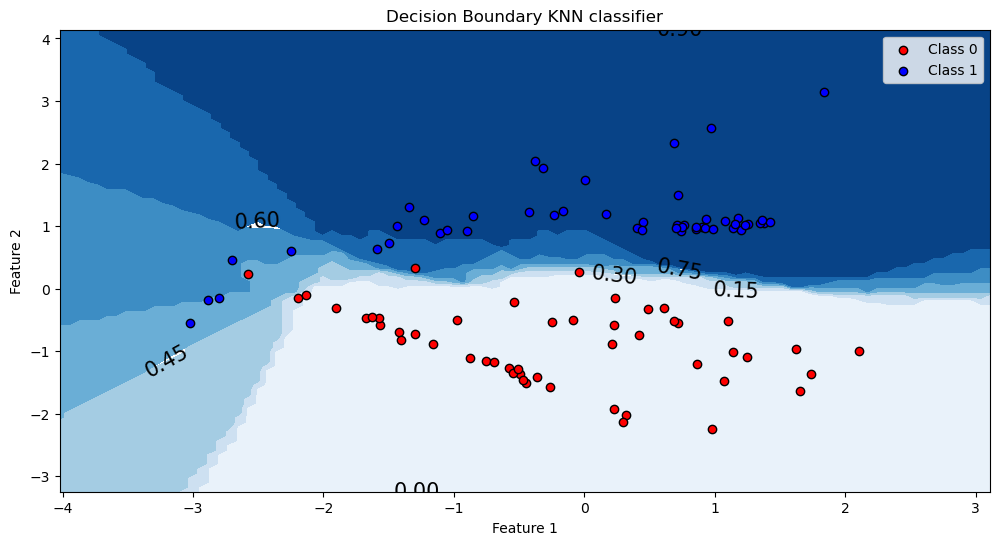

In [4]:
model_2 = KNeighborsClassifier(n_neighbors=8,
                              p=2, 
                              weights='uniform')
model_2.fit(X,y)

plt.figure(figsize=(12, 6))
disp= DecisionBoundaryDisplay.from_estimator(model_2,
                                      X,
                                      response_method='predict_proba',
                                      plot_method='contourf' ,
                                      ax=plt.gca(),
                                      cmap='Blues')
plt.clabel(disp.surface_, inline=True, fontsize=15, fmt='%.2f', colors='black')
plt.scatter(X[y == 0, 0], X[y == 0, 1], c='red', label='Class 0', edgecolor='k')
plt.scatter(X[y == 1, 0], X[y == 1, 1], c='blue', label='Class 1', edgecolor='k')
plt.xlabel('Feature 1')
plt.title('Decision Boundary KNN classifier')
plt.ylabel('Feature 2')
plt.legend()
plt.show()


here the knn probability is number of class 1 neighobrs / K neighbors

When weight ='distance' "Closer neighbors get a heavier vote (more influence) than farther neighbors."

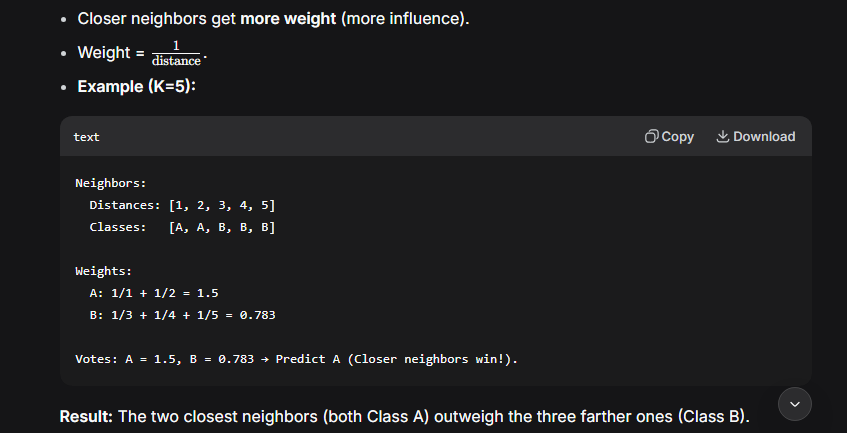

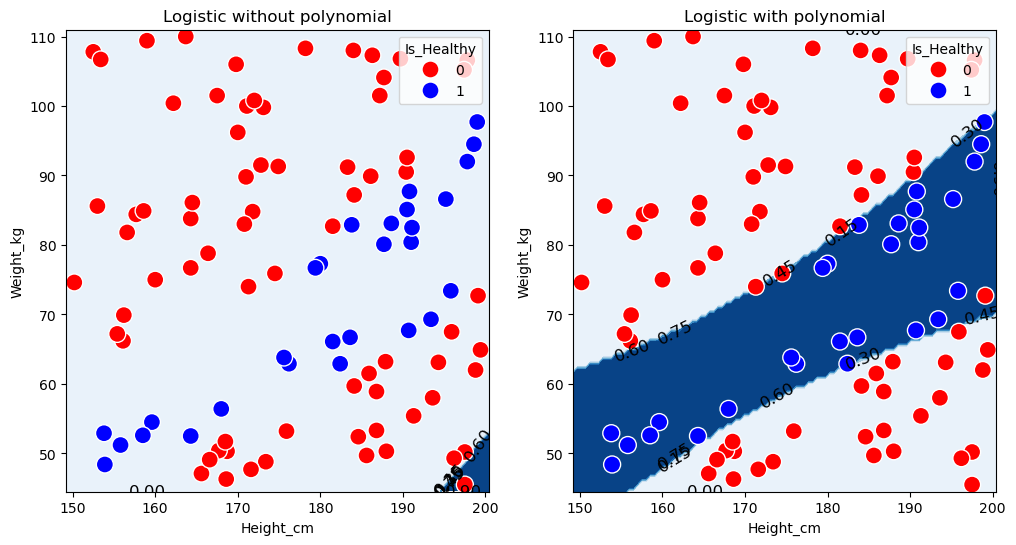

In [5]:
heights = np.random.uniform(150, 200, 100)
weights = np.random.uniform(45, 110, 100)

df = pd.DataFrame({
    'Height_cm': np.round(heights, 1),
    'Weight_kg': np.round(weights, 1)
})
bmi = df['Weight_kg'] / ((df['Height_cm'] / 100) ** 2)

df['Is_Healthy'] = np.where((bmi >= 18.5) & (bmi <= 24.9), 1, 0)
model = LogisticRegression()
X = df.drop( columns ='Is_Healthy') 
y = df['Is_Healthy']
model.fit(X, y)
model_2.fit(X,y)
fig, ax = plt.subplots( 1,2, figsize= (12,6))
disp= DecisionBoundaryDisplay.from_estimator(model,
                                      X,
                                      response_method='predict',
                                      plot_method='contourf' ,
                                      ax=ax[0],
                                      cmap='Blues')
ax[0].clabel(disp.surface_, inline=True, fontsize=12, fmt='%.2f', colors='black')
sns.scatterplot(data = df , 
                x='Height_cm' ,
                y='Weight_kg', 
                hue= 'Is_Healthy',
                s = 150, 
                palette=['Red' ,'Blue'] ,
                ax=ax[0]
               )
model_3 = Pipeline([( 'pol' , PolynomialFeatures(degree=2,
                                                 include_bias=False) ),
                    ('log_pol' , LogisticRegression(max_iter=250)) ])
model_3.fit(X,y)
disp= DecisionBoundaryDisplay.from_estimator(model_3,
                                      X,
                                      response_method='predict',
                                      plot_method='contourf' ,
                                      ax=ax[1],
                                      cmap='Blues')
ax[1].clabel(disp.surface_, inline=True, fontsize=12, fmt='%.2f', colors='black')
ax[1].set_title('Logistic with polynomial')
ax[0].set_title('Logistic without polynomial')
sns.scatterplot(data = df , 
                x='Height_cm' ,
                y='Weight_kg', 
                hue= 'Is_Healthy',
                s = 150, 
                palette=['Red' ,'Blue'] ,
                ax=ax[1]
               )
plt.show()

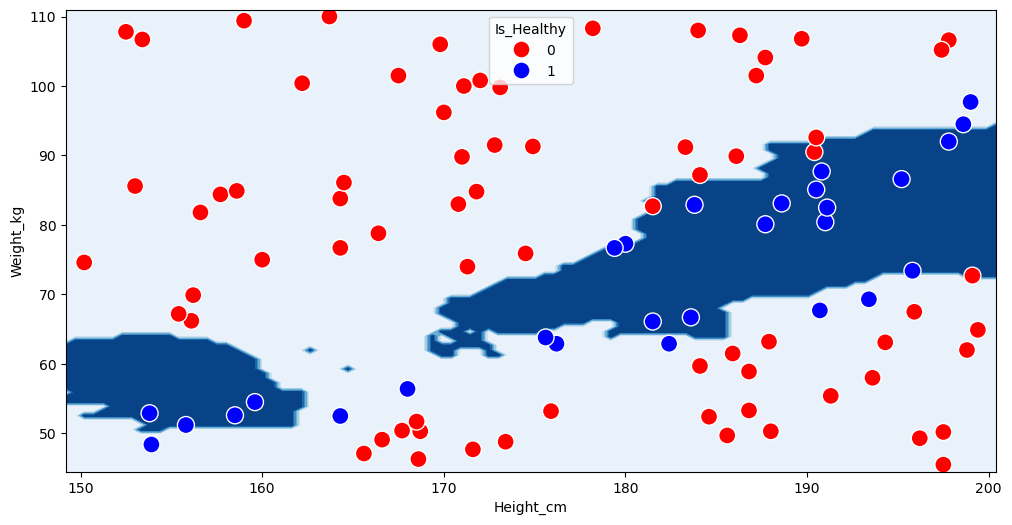

In [6]:
#with knn 
model = KNeighborsClassifier( n_neighbors=12) 
model.fit(X,y)
plt.figure( figsize =(12,6) ) 

disp = DecisionBoundaryDisplay.from_estimator( model, 
                                               X,
                                               response_method='predict' , 
                                               plot_method='contourf' , 
                                               cmap ='Blues', 
                                               ax = plt.gca() )
sns.scatterplot( data = df , 
                 x='Height_cm' ,
                 y='Weight_kg', 
                 hue= 'Is_Healthy',
                 s = 150, 
                 palette=['Red' ,'Blue'] )
plt.show()

Because the relationship between the classes is not linear the logistic regression is failing 
"The relationship between Height, Weight, and the log-odds of being Healthy is linear, but the relationship between Height, Weight, and the probability of being Healthy is non-linear."

In [7]:
recall_score( y, model.predict(X)), recall_score( y, model_3.predict(X))

(0.6071428571428571, 1.0)